In [1]:
!pip install sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 11.1 MB/s eta 0:00:00a 0:00:01


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import sentencepiece as spm

import math
import os
import re
import urllib.request
import zipfile
import numpy as np
import matplotlib.pyplot as plt

### **Positional Encoding**

In [3]:
class PositionalEncoding(nn.Module):
    def __init__(self, position, d_model):
        super(PositionalEncoding, self).__init__()
        self.d_model = d_model
        self.position = position

        self.pos_encoding = self._build_pos_encoding(position, d_model)

    def _get_angles(self, position, i, d_model):
        return 1.0 / (10000.0 ** ((2.0 * (i // 2)) / d_model)) * position

    def _build_pos_encoding(self, position, d_model):
        pos = torch.arange(position, dtype=torch.float32).unsqueeze(1)
        i = torch.arange(d_model, dtype=torch.float32).unsqueeze(0)

        angle_rads = self._get_angles(pos, i, d_model)
        sines = torch.sin(angle_rads[:, 0::2])
        cosines = torch.cos(angle_rads[:, 1::2])

        pos_encoding = torch.zeros(position, d_model)
        pos_encoding[:, 0::2] = sines
        pos_encoding[:, 1::2] = cosines

        pos_encoding = pos_encoding.unsqueeze(0)  # shape: [1, position, d_model]
        return pos_encoding

    def forward(self, x):
        return x + self.pos_encoding[:, :x.size(1), :].to(x.device)

### **Scaled Dot Product**

In [4]:
def scaled_dot_product_attention(query, key, value, mask=None):

    # 1) Q와 K의 내적을 통해 score(유사도) 계산
    # key.transpose(-1, -2): (batch_size, heads, depth, seq_len)
    # matmul 결과 shape: (batch_size, heads, seq_len, seq_len)
    matmul_qk = torch.matmul(query, key.transpose(-1, -2))

    # 2) depth에 따라 정규화
    depth = key.size(-1)  # depth = d_model / heads
    logits = matmul_qk / math.sqrt(depth)

    # 3) 마스크가 주어졌다면 -1e9(아주 작은 값)를 더해 소프트맥스에서 제외시키도록 함
    if mask is not None:
        # 텐서플로우: logits += (mask * -1e9)
        # 파이토치 동일 적용
        logits = logits + (mask * -1e9)

    # 4) 소프트맥스 계산해 attention weights 생성
    attention_weights = F.softmax(logits, dim=-1)

    # 5) attention weights와 value의 내적
    output = torch.matmul(attention_weights, value)

    return output, attention_weights

### **MultiHeadAttention**

In [5]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, name="multi_head_attention"):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model은 num_heads로 나누어떨어져야 함
        assert d_model % num_heads == 0

        self.depth = d_model // num_heads

        # 파이토치에서 Dense는 nn.Linear로 대응
        self.query_dense = nn.Linear(d_model, d_model)
        self.key_dense = nn.Linear(d_model, d_model)
        self.value_dense = nn.Linear(d_model, d_model)

        self.out_dense = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        """
        x: (batch_size, seq_len, d_model)
        => (batch_size, num_heads, seq_len, depth) 형태로 변환
        """
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)  # (batch_size, num_heads, seq_len, depth)
        return x

    def forward(self, query, key, value, mask=None):
        """
        query, key, value: (batch_size, seq_len, d_model)
        mask: (batch_size, 1, seq_len, seq_len) 등으로 broadcast 가능하도록 구성
        """
        batch_size = query.size(0)

        # Q, K, V에 각각 Linear 적용
        query = self.query_dense(query)
        key = self.key_dense(key)
        value = self.value_dense(value)

        # Head 분할
        query = self.split_heads(query, batch_size)
        key = self.split_heads(key, batch_size)
        value = self.split_heads(value, batch_size)

        # 스케일드 닷 프로덕트 어텐션
        scaled_attention, _ = scaled_dot_product_attention(query, key, value, mask)

        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        scaled_attention = scaled_attention.permute(0, 2, 1, 3).contiguous()

        # 다시 (batch_size, seq_len, d_model)로 합치기
        concat_attention = scaled_attention.view(batch_size, -1, self.d_model)

        # 최종 Dense
        output = self.out_dense(concat_attention)
        return output


### **Padding**

In [6]:
def create_padding_mask(x):
    # x == 0 위치를 찾아 float형 1로 변환
    mask = (x == 0).float()
    # (batch_size, seq_len) -> (batch_size, 1, 1, seq_len)
    mask = mask.unsqueeze(1).unsqueeze(2)
    return mask


def create_look_ahead_mask(x):
    seq_len = x.size(1)

    # (seq_len, seq_len) 크기의 하삼각 행렬(tril) 생성 후 1에서 빼서
    # 상삼각이 1, 하삼각(자기 자신 포함)이 0이 되도록 설정
    # => 미래 토큰(자신 인덱스보다 큰 위치) 마스킹
    look_ahead_mask = 1 - torch.tril(torch.ones((seq_len, seq_len)))

    # 패딩 마스크 생성 (shape: (batch_size, 1, 1, seq_len))
    padding_mask = create_padding_mask(x)

    # look_ahead_mask: (seq_len, seq_len) -> (1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(0)
    # -> (1, seq_len, seq_len) -> (1, 1, seq_len, seq_len)
    look_ahead_mask = look_ahead_mask.unsqueeze(1)
    look_ahead_mask = look_ahead_mask.to(x.device)

    # look-ahead 마스크와 패딩 마스크를 합성 (둘 중 하나라도 1이면 마스킹)
    # 최종 shape은 브로드캐스팅으로 (batch_size, 1, seq_len, seq_len)
    combined_mask = torch.max(look_ahead_mask, padding_mask)
    return combined_mask

### **Encoder**

In [7]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(EncoderLayer, self).__init__()
        self.mha = MultiHeadAttention(d_model, num_heads)  # 이전에 구현한 MHA
        self.dropout1 = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        # 피드포워드 부분 (Dense -> ReLU -> Dense)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, d_model)
        )
        self.dropout2 = nn.Dropout(dropout)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x, mask=None):
        # (1) 멀티 헤드 어텐션 (셀프 어텐션)
        attn_output = self.mha(x, x, x, mask)  # (batch_size, seq_len, d_model)
        attn_output = self.dropout1(attn_output)
        out1 = self.norm1(x + attn_output)     # 잔차 연결 + LayerNorm

        # (2) 피드포워드 신경망
        ffn_output = self.ffn(out1)            # (batch_size, seq_len, d_model)
        ffn_output = self.dropout2(ffn_output)
        out2 = self.norm2(out1 + ffn_output)   # 잔차 연결 + LayerNorm

        return out2


In [8]:
class Encoder(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,
                 ff_dim,
                 d_model,
                 num_heads,
                 dropout=0.1):
        super(Encoder, self).__init__()
        self.d_model = d_model

        # (1) 임베딩 레이어
        self.embedding = nn.Embedding(vocab_size, d_model)

        # (2) 포지셔널 인코딩
        self.pos_encoding = PositionalEncoding(position=vocab_size, d_model=d_model)

        self.dropout = nn.Dropout(dropout)

        # (3) EncoderLayer 쌓기
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, mask=None):
        # (1) 임베딩 & sqrt(d_model)로 스케일링
        x = self.embedding(x) * math.sqrt(self.d_model)

        # (2) 포지셔널 인코딩 적용 + 드롭아웃
        x = self.pos_encoding(x)  # shape: (batch_size, seq_len, d_model)
        x = self.dropout(x)

        # (3) num_layers만큼 쌓아올린 EncoderLayer 통과
        for layer in self.enc_layers:
            x = layer(x, mask)

        return x



### **Decoder**

In [355]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super(DecoderLayer, self).__init__()

        # 첫 번째 서브 레이어 (디코더 내부 셀프 어텐션)
        self.self_mha = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model, eps=1e-6)

        # 두 번째 서브 레이어 (인코더-디코더 어텐션)
        self.encdec_mha = MultiHeadAttention(d_model, num_heads)
        self.norm2 = nn.LayerNorm(d_model, eps=1e-6)

        # 세 번째 서브 레이어 (피드포워드 네트워크)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),  # Dense(units=ff_dim)
            nn.ReLU(),                   # activation='relu'
            nn.Linear(ff_dim, d_model)   # Dense(units=d_model)
        )
        self.norm3 = nn.LayerNorm(d_model, eps=1e-6)

        # 드롭아웃
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        # 1) 셀프 어텐션 (디코더 내부)
        self_attn_out = self.self_mha(x, x, x, mask=look_ahead_mask)
        self_attn_out = self.dropout1(self_attn_out)
        out1 = self.norm1(x + self_attn_out)  # 잔차 연결 + LayerNorm

        # 2) 인코더-디코더 어텐션
        encdec_attn_out = self.encdec_mha(out1, enc_outputs, enc_outputs, mask=padding_mask)
        encdec_attn_out = self.dropout2(encdec_attn_out)
        out2 = self.norm2(out1 + encdec_attn_out)  # 잔차 연결 + LayerNorm

        # 3) 피드포워드 (Dense -> ReLU -> Dense)
        ffn_out = self.ffn(out2)
        ffn_out = self.dropout3(ffn_out)
        out3 = self.norm3(out2 + ffn_out)  # 잔차 연결 + LayerNorm

        return out3

In [357]:
class Decoder(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,
                 ff_dim,
                 d_model,
                 num_heads,
                 dropout=0.1):
        super(Decoder, self).__init__()
        self.d_model = d_model

        # (1) 임베딩 레이어
        self.embedding = nn.Embedding(vocab_size, d_model)

        # (2) 포지셔널 인코딩
        # 실제 학습 시에는 최대 시퀀스 길이에 맞추어 쓰기도 함
        self.pos_encoding = PositionalEncoding(position=vocab_size, d_model=d_model)

        self.dropout = nn.Dropout(dropout)

        # (3) DecoderLayer 쌓기
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x, enc_outputs, look_ahead_mask=None, padding_mask=None):
        # (1) 임베딩 + sqrt(d_model)로 스케일링
        x = self.embedding(x) * math.sqrt(self.d_model)

        # (2) 포지셔널 인코딩 + 드롭아웃
        x = self.pos_encoding(x)    # (batch_size, tgt_seq_len, d_model)
        x = self.dropout(x)

        # (3) num_layers만큼 쌓인 DecoderLayer 통과
        for layer in self.dec_layers:
            x = layer(x, enc_outputs, look_ahead_mask, padding_mask)

        return x

- encoder : 문장을 읽고 정보를 압축하는 모듈
- decoder : 압축된 정보를 바탕으로 출력 sequence를 만드는 역할을 하는 모듈
- context vecotor : 압축된 정보

In [358]:
# mkdir -p ~/work/transformer_chatbot/data/ && cd ~/work/transformer_chatbot/data/

In [359]:
!wget https://github.com/songys/Chatbot_data/raw/master/ChatbotData.csv

--2026-04-20 04:02:24--  https://github.com/songys/Chatbot_data/raw/master/ChatbotData.csv
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv [following]
--2026-04-20 04:02:24--  https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 889842 (869K) [text/plain]
Saving to: ‘ChatbotData.csv.4’

ChatbotData.csv.4   100%[===================>] 868.99K  --.-KB/s    in 0.1s    

2026-04-20 04:02:24 (5.69 MB/s) - ‘ChatbotData.csv.4’ saved [889842/889842]



In [360]:
torch.manual_seed(20260420)

In [361]:
import pandas as pd
data=pd.read_csv('ChatbotData.csv')

In [362]:
data

,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0
...,...,...,...
11818,훔쳐보는 것도 눈치 보임.,티가 나니까 눈치가 보이는 거죠!,2
11819,훔쳐보는 것도 눈치 보임.,훔쳐보는 거 티나나봐요.,2
11820,흑기사 해주는 짝남.,설렜겠어요.,2
11821,힘든 연애 좋은 연애라는게 무슨 차이일까?,잘 헤어질 수 있는 사이 여부인 거 같아요.,2


### - 챗봇 트레이닝용 문답 페어 11,823개  
### - 일상다반사 0, 이별(부정) 1, 사랑(긍정) 2로 레이블링

In [363]:
import copy
data_origin = copy.deepcopy(data)

## **Step 2.데이터 전처리하기**

In [364]:
# 전처리 함수
def preprocess_sentence_eng(sentence):
  # 입력받은 sentence를 소문자로 변경하고 양쪽 공백을 제거
  sentence = sentence.lower().strip()

  # 단어와 구두점(punctuation) 사이의 거리를 만듭니다.
  # 예를 들어서 "I am a student." => "I am a student ."와 같이
  # student와 온점 사이에 거리를 만듭니다.
  sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
  sentence = re.sub(r'[" "]+', " ", sentence)

  # (a-z, A-Z, ".", "?", "!", ",")를 제외한 모든 문자를 공백인 ' '로 대체합니다.
  sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)
  sentence = sentence.strip()
  return sentence

def preprocess_sentence_kor(sentence):
    # 양쪽 공백 제거
    sentence = sentence.strip()

    # 구두점 앞뒤에 공백 추가
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)

    # 여러 공백 하나로
    sentence = re.sub(r"\s+", " ", sentence)

    # 한글, 영어, 숫자, 구두점만 남기기
    sentence = re.sub(r"[^가-힣a-zA-Z0-9?.!,]+", " ", sentence)

    # 다시 공백 정리
    sentence = sentence.strip()
    
    return sentence

In [365]:
data['Q'] = data['Q'].apply(preprocess_sentence_kor)
data['A'] = data['A'].apply(preprocess_sentence_kor)

In [366]:
pairs = list(zip(data['Q'], data['A']))

In [367]:
pairs[:5]

[('12시 땡 !', '하루가 또 가네요 .'),
 ('1지망 학교 떨어졌어', '위로해 드립니다 .'),
 ('3박4일 놀러가고 싶다', '여행은 언제나 좋죠 .'),
 ('3박4일 정도 놀러가고 싶다', '여행은 언제나 좋죠 .'),
 ('PPL 심하네', '눈살이 찌푸려지죠 .')]

In [368]:
print('전체 샘플 수 :', len(pairs))

전체 샘플 수 : 11823


In [369]:
# 길이가 2이하인 문장은 제거
pairs = [
    (q, a)
    for q, a in pairs
    if len(q.split()) >= 2 and len(a.split()) >= 2
]

In [370]:
print('전체 샘플 수 :', len(pairs))

전체 샘플 수 : 11313


In [371]:
data.isnull().sum()

Q        0
A        0
label    0
dtype: int64

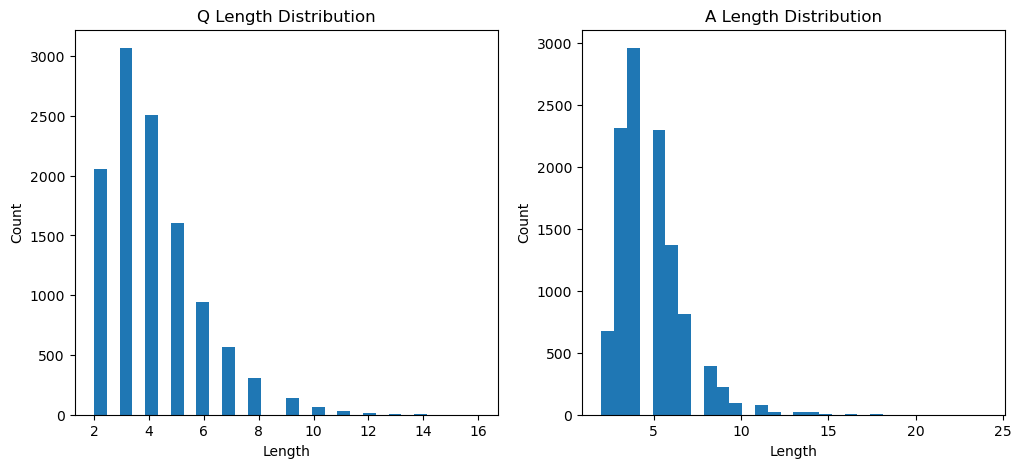

In [372]:
q_lengths = [len(q.split()) for q, a in pairs]
a_lengths = [len(a.split()) for q, a in pairs]

plt.figure(figsize=(12, 5))

# 질문 길이
plt.subplot(1, 2, 1)
plt.hist(q_lengths, bins=30)
plt.title("Q Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")

# 답변 길이
plt.subplot(1, 2, 2)
plt.hist(a_lengths, bins=30)
plt.title("A Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")

plt.show()

In [373]:
print("Q 평균:", sum(q_lengths)/len(q_lengths))
print("A 평균:", sum(a_lengths)/len(a_lengths))
print("Q 최대:", max(q_lengths))
print("A 최대:", max(a_lengths))

Q 평균: 4.067709714487758
A 평균: 4.7501104923539295
Q 최대: 16
A 최대: 24


In [374]:
def build_chatbot_pairs_fast(csv_path, max_samples=50000):
    data = pd.read_csv(csv_path)

    # 전처리 한 번에
    data['Q'] = data['Q'].apply(preprocess_sentence)
    data['A'] = data['A'].apply(preprocess_sentence)

    # tuple로 변환
    pairs = list(zip(data['Q'], data['A']))

    return pairs[:max_samples]

## **Step 3. StentencePiece 사용하기**

In [375]:
corpus_file = "clean_kor_corpus.txt"
with open(corpus_file, 'w', encoding='utf-8') as f:
    for q, a in pairs:
        f.write(q + "\n")
        f.write(a + "\n")

In [376]:
corpus_file

'clean_kor_corpus.txt'

In [377]:
spm.SentencePieceTrainer.Train(
    input="clean_kor_corpus.txt",
    model_prefix="spm_korean",
    vocab_size=8000,
    character_coverage=0.9995,   # ⭐ 수정
    model_type="unigram",        # ⭐ 추천
    max_sentence_length=999999,
    bos_id=1,
    eos_id=2,
    pad_id=0,
    unk_id=3
)

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: clean_kor_corpus.txt
  input_format: 
  model_prefix: spm_korean
  model_type: UNIGRAM
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 999999
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy

In [378]:
sp = spm.SentencePieceProcessor()
sp.Load("spm_korean.model")

True

In [379]:
for i in range(20):
    print(sp.id_to_piece(i))

<pad>
<s>
</s>
<unk>
▁.
요
▁
▁?
을
가
도
이
는
세요
게
고
▁거예요
를
은
지


In [380]:
# 예제 문장
sentence = "안녕하세요, 만나서 반갑습니다 !"
sentence = preprocess_sentence_kor(sentence)
print("전처리 후의 문장:", sentence)

# 1. 토크나이징 (subword 단위로 분할)
tokens = sp.encode(sentence, out_type=str)
print("Tokenized:", tokens)

# 2. 인코딩 (서브워드를 정수 ID로 변환)
encoded = sp.encode(sentence, out_type=int)
print("Encoded:", encoded)

# 3. 디코딩 (정수 ID → 원본 문장 복원)
decoded = sp.decode(encoded)
print("Decoded:", decoded)

전처리 후의 문장: 안녕하세요 , 만나서 반갑습니다 !
Tokenized: ['▁안녕', '하', '세요', '▁,', '▁만나', '서', '▁반갑', '습니다', '▁!']
Encoded: [947, 310, 13, 219, 162, 27, 4147, 426, 51]
Decoded: 안녕하세요 , 만나서 반갑습니다 !


In [381]:
class WellnessDataset(Dataset):
    def __init__(self, pairs, sp, max_length=26):
        super().__init__()
        self.sp = sp
        self.max_length = max_length
        self.data = []

        for q_text, a_text in pairs:
            # 1) 토크나이즈, 정수 인코딩
            q_ids = sp.EncodeAsIds(q_text)
            a_ids = sp.EncodeAsIds(a_text)

            # 2) [CLS]/[SEP] 같은 별도 스페셜 토큰을 쓸 수도 있으나,
            #    여기서는 SentencePiece 기본 <s>, </s> 등 혹은 사용자 정의 토큰 활용 가능
            #    간단히 <s>=sp.bos_id(), </s>=sp.eos_id()로 가정해본다면:
            #    sp.SetEncodeExtraOptions("bos:eos") 등으로 설정하는 방법도 있음.
            # 여기서는 수동으로 bos/eos id를 붙인다고 가정
            bos_id = sp.bos_id() if sp.bos_id() >= 0 else 1  # 혹은 임의값
            eos_id = sp.eos_id() if sp.eos_id() >= 0 else 2

            q_tokens = [bos_id] + q_ids + [eos_id]
            a_tokens = [bos_id] + a_ids + [eos_id]

            # 3) 길이 제한
            if len(q_tokens) > max_length or len(a_tokens) > max_length:
                continue

            # # 4) 고정 길이 패딩
            # q_tokens += [0]*(max_length - len(q_tokens))  # 0 -> <pad> 가정
            # a_tokens += [0]*(max_length - len(a_tokens))

            pad_id = sp.pad_id()
            
            q_tokens += [pad_id] * (max_length - len(q_tokens))
            a_tokens += [pad_id] * (max_length - len(a_tokens))


            # enc_mask = [1 if token != pad_id else 0 for token in q_tokens]
            # dec_mask = [1 if token != pad_id else 0 for token in dec_input]
            
            # 5) 디코더 입력(dec_input): a_tokens[:-1], 타겟(outputs): a_tokens[1:]
            #    (teacher forcing용)
            dec_input = a_tokens[:-1]
            target = a_tokens[1:]

            self.data.append({
                "enc_input": q_tokens,
                "dec_input": dec_input,
                "target": target
            })

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        enc_input = torch.tensor(sample["enc_input"], dtype=torch.long)
        dec_input = torch.tensor(sample["dec_input"], dtype=torch.long)
        target = torch.tensor(sample["target"], dtype=torch.long)
        return enc_input, dec_input, target

In [382]:
print("BOS ID:", sp.bos_id())
print("EOS ID:", sp.eos_id())
print("PAD ID:", sp.pad_id())
print("UNK ID:", sp.unk_id())

BOS ID: 1
EOS ID: 2
PAD ID: 0
UNK ID: 3


In [383]:
# Dataset 구현하기
dataset = WellnessDataset(pairs, sp, max_length=26)

In [384]:
# # for encoder_input, decoder_input, decoder_label,_  in dataset:
# for encoder_input, decoder_input, decoder_label, enc_mask, dec_mask in dataset:
#     print("텐서 크기 :",encoder_input.size())
#     print()
#     print(encoder_input)
#     print(sp.decode(encoder_input.tolist()))
#     print('--------------------------------------------------------------------')
#     print(decoder_input)
#     print(sp.decode(decoder_input.tolist()))
#     print('--------------------------------------------------------------------')
#     print(decoder_label)
#     print(sp.decode(decoder_label.tolist()))
#     break

In [385]:
# DataLoader 구성하기
dataloader = DataLoader(dataset,batch_size=32,shuffle=True)

In [386]:
dataloader

In [387]:
for encoder_input, decoder_input, decoder_label in dataloader:
    print(encoder_input.size())
    print(decoder_input.size())
    print(decoder_label.size())
    break

torch.Size([32, 26])
torch.Size([32, 25])
torch.Size([32, 25])


- answer는 답이 한개씩 밀려서 decoer_size=encoder_size-1개가 된다

In [388]:
print("Vocab size:", sp.GetPieceSize())
print("BOS:", sp.bos_id(), sp.id_to_piece(sp.bos_id()))
print("EOS:", sp.eos_id(), sp.id_to_piece(sp.eos_id()))

Vocab size: 8000
BOS: 1 <s>
EOS: 2 </s>


### **Transformer 모델 구축**

In [389]:
class Transformer(nn.Module):
    def __init__(self,
                 vocab_size,
                 num_layers,      # 인코더/디코더 층 수
                 units,           # feed-forward 네트워크의 중간 차원(ff_dim)
                 d_model,         # 임베딩 및 내부 표현 차원
                 num_heads,       # 멀티헤드 어텐션의 헤드 수
                 dropout=0.1):
        super(Transformer, self).__init__()

        # 인코더
        self.encoder = Encoder(
            vocab_size=vocab_size,
            num_layers=num_layers,
            ff_dim=units,
            d_model=d_model,
            num_heads=num_heads,
            dropout=dropout
        )

        # 디코더
        self.decoder = Decoder(
            vocab_size=vocab_size,
            num_layers=num_layers,
            ff_dim=units,
            d_model=d_model,
            num_heads=num_heads,
            dropout=dropout
        )

        # 최종 출력층: (d_model) -> (vocab_size)
        self.final_linear = nn.Linear(d_model, vocab_size)

        # 참고: 텐서플로우 코드의 `name="transformer"`는 파이토치에선 보통 사용 안 함

    def forward(self, inputs, dec_inputs):
        # 1) 인코더 패딩 마스크 생성
        enc_padding_mask = create_padding_mask(inputs)     # shape (batch_size, 1, 1, src_seq_len)

        # 2) 디코더 look-ahead + 패딩 마스크
        look_ahead_mask = create_look_ahead_mask(dec_inputs)  # shape (batch_size, 1, tgt_seq_len, tgt_seq_len)

        # 3) 디코더에서 인코더 출력 쪽을 마스킹할 때 쓸 패딩 마스크
        dec_padding_mask = create_padding_mask(inputs)        # shape (batch_size, 1, 1, src_seq_len)

        # 4) 인코더 수행
        enc_outputs = self.encoder(
            x=inputs,
            mask=enc_padding_mask
        )  # shape: (batch_size, src_seq_len, d_model)

        # 5) 디코더 수행
        dec_outputs = self.decoder(
            x=dec_inputs,           # (batch_size, tgt_seq_len)
            enc_outputs=enc_outputs,# (batch_size, src_seq_len, d_model)
            look_ahead_mask=look_ahead_mask,
            padding_mask=dec_padding_mask
        )  # shape: (batch_size, tgt_seq_len, d_model)

        # 6) 최종 Dense (vocab_size)
        logits = self.final_linear(dec_outputs)  # (batch_size, tgt_seq_len, vocab_size)
        return logits

In [390]:
print(sp.GetPieceSize())

8000


In [391]:
# 예: 하이퍼파라미터 설정
NUM_LAYERS = 4     # 인코더/디코더 층 수
D_MODEL = 256      # 임베딩 및 내부 표현 차원
NUM_HEADS = 8      # 멀티헤드 어텐션에서의 헤드 수
UNITS = 256        # 피드포워드 신경망의 은닉 차원
DROPOUT = 0.1      # 드롭아웃 비율
VOCAB_SIZE = 8000 # 단어 집합 크기(예시)

# 모델 생성
model = Transformer(
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS,
    units=UNITS,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    dropout=DROPOUT
)

print(model)

Transformer(
  (encoder): Encoder(
    (embedding): Embedding(8000, 256)
    (pos_encoding): PositionalEncoding()
    (dropout): Dropout(p=0.1, inplace=False)
    (enc_layers): ModuleList(
      (0-3): 4 x EncoderLayer(
        (mha): MultiHeadAttention(
          (query_dense): Linear(in_features=256, out_features=256, bias=True)
          (key_dense): Linear(in_features=256, out_features=256, bias=True)
          (value_dense): Linear(in_features=256, out_features=256, bias=True)
          (out_dense): Linear(in_features=256, out_features=256, bias=True)
        )
        (dropout1): Dropout(p=0.1, inplace=False)
        (norm1): LayerNorm((256,), eps=1e-06, elementwise_affine=True)
        (ffn): Sequential(
          (0): Linear(in_features=256, out_features=256, bias=True)
          (1): ReLU()
          (2): Linear(in_features=256, out_features=256, bias=True)
        )
        (dropout2): Dropout(p=0.1, inplace=False)
        (norm2): LayerNorm((256,), eps=1e-06, elementwise_aff

In [392]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = model.to(device)

In [393]:
def train_step(model, batch, optimizer, loss_function, device):
    model.train()
    enc_input, dec_input, target = [x.to(device) for x in batch]

    optimizer.zero_grad()

    # 모델 포워드 패스
    logits = model(enc_input, dec_input)  # (batch_size, seq_len, vocab_size)

    # Loss 계산 (패딩 토큰 무시)
    loss = loss_function(logits.permute(0, 2, 1), target)  # (batch_size, vocab_size, seq_len) 필요

    # Backpropagation
    loss.backward()
    optimizer.step()

    return loss.item(), accuracy_function(logits, target, pad_id=sp.pad_id())

In [394]:
def train(model, dataloader, optimizer, loss_function, scheduler, num_epochs, device):
    model.to(device)

    for epoch in range(num_epochs):
        total_loss, total_acc = 0, 0
        for step, batch in enumerate(dataloader):
            loss, acc = train_step(model, batch, optimizer, loss_function, device)
            total_loss += loss
            total_acc += acc

            # 일정 스텝마다 로그 출력
            if step % 100 == 0:
                print(f"[Epoch {epoch+1}, Step {step}] Loss: {loss:.4f}, Acc: {acc:.4f}")

            # 학습률 스케줄러 업데이트
            scheduler.step()

        avg_loss = total_loss / len(dataloader)
        avg_acc = total_acc / len(dataloader)
        print(f"Epoch {epoch+1} Completed - Avg Loss: {avg_loss:.4f}, Avg Acc: {avg_acc:.4f}")

In [395]:
def train2(model, dataloader, optimizer, loss_function, scheduler, num_epochs, device):
    model.to(device)

    loss_history = []  # ⭐ 추가
    acc_history = []   # (선택) accuracy도 저장

    for epoch in range(num_epochs):
        total_loss, total_acc = 0, 0

        for step, batch in enumerate(dataloader):
            loss, acc = train_step(model, batch, optimizer, loss_function, device)

            total_loss += loss
            total_acc += acc

            # 로그 출력
            if step % 100 == 0:
                print(f"[Epoch {epoch+1}, Step {step}] Loss: {loss:.4f}, Acc: {acc:.4f}")

            # 스케줄러 업데이트
            scheduler.step()

        avg_loss = total_loss / len(dataloader)
        avg_acc = total_acc / len(dataloader)

        loss_history.append(avg_loss)  # ⭐ 저장
        acc_history.append(avg_acc)    # ⭐ 저장

        print(f"Epoch {epoch+1} Completed - Avg Loss: {avg_loss:.4f}, Avg Acc: {avg_acc:.4f}")

    return loss_history, acc_history  # ⭐ 반환

In [413]:
#######################################
######### Hyper #######################
#######################################


# 손실 함수(Loss function) :레이블인 시퀀스에 패딩이 되어 있으므로, loss를 계산할 때 패딩 마스크를 적용
loss_function = nn.CrossEntropyLoss(ignore_index=sp.pad_id())
EPOCH = 30
# 커스텀 된 학습률(Learning rate)
def get_lr_lambda(d_model, warmup_steps=4000):
    d_model = float(d_model)
    def lr_lambda(step):
        # step은 0부터 시작하므로 +1로 보정
        step = step + 1
        return (d_model ** -0.5) * min(step ** -0.5, step * (warmup_steps ** -1.5))
    return lr_lambda

# Optimizer 정의
optimizer = optim.Adam(model.parameters(), betas=(0.9, 0.98), eps=1e-9)
optimizer = optim.Adam(model.parameters(), lr=1)
# 
# Scheduler 정의
scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr_lambda(D_MODEL, warmup_steps=4000))

def accuracy_function(y_pred, y_true, pad_id=0):
    """
    y_pred: (batch_size, seq_len, vocab_size)
    y_true: (batch_size, seq_len)
    """
    preds = y_pred.argmax(dim=-1)  # (batch_size, seq_len)
    mask = (y_true != pad_id)
    correct = (preds == y_true) & mask
    acc = correct.float().sum() / mask.float().sum()
    return acc

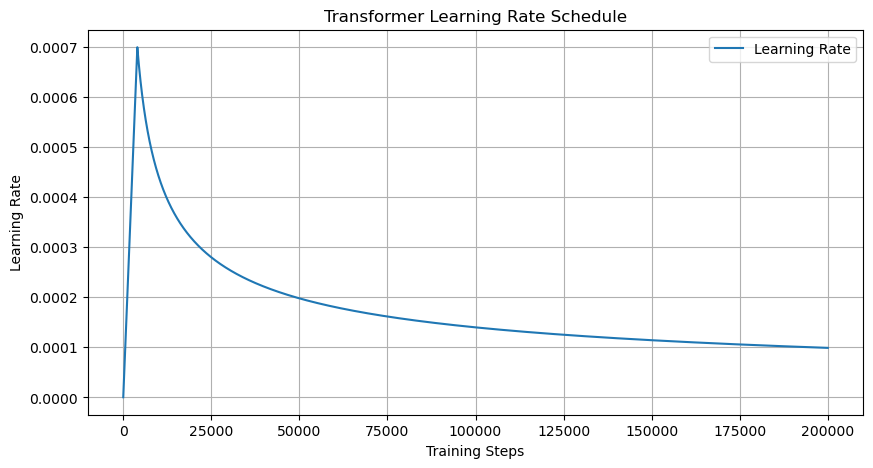

In [414]:
# 하이퍼파라미터 설정
d_model = 512
warmup_steps = 4000
total_steps = 200000  # 총 학습 스텝

# 학습률 스케줄 시각화
steps = np.arange(1, total_steps + 1)
learning_rates = [get_lr_lambda(d_model, warmup_steps)(step) for step in steps]

# 그래프 출력
plt.figure(figsize=(10, 5))
plt.plot(steps, learning_rates, label="Learning Rate")
plt.xlabel("Training Steps")
plt.ylabel("Learning Rate")
plt.title("Transformer Learning Rate Schedule")
plt.legend()
plt.grid(True)
plt.show()

In [415]:
%%time

train(
    model=model,
    dataloader=dataloader,
    optimizer=optimizer,
    loss_function=loss_function,
    scheduler=scheduler,
    num_epochs=EPOCH,  # 원하는 에폭 수
    device=device
)

[Epoch 1, Step 0] Loss: 5.9346, Acc: 0.2778
[Epoch 1, Step 100] Loss: 6.1439, Acc: 0.2273
[Epoch 1, Step 200] Loss: 5.6513, Acc: 0.2562
[Epoch 1, Step 300] Loss: 5.5280, Acc: 0.2606
Epoch 1 Completed - Avg Loss: 5.7761, Avg Acc: 0.2508
[Epoch 2, Step 0] Loss: 5.3975, Acc: 0.2407
[Epoch 2, Step 100] Loss: 5.3468, Acc: 0.2590
[Epoch 2, Step 200] Loss: 5.0490, Acc: 0.3052
[Epoch 2, Step 300] Loss: 5.1682, Acc: 0.3097
Epoch 2 Completed - Avg Loss: 5.0291, Avg Acc: 0.3012
[Epoch 3, Step 0] Loss: 4.5983, Acc: 0.3412
[Epoch 3, Step 100] Loss: 4.6737, Acc: 0.3238
[Epoch 3, Step 200] Loss: 4.4855, Acc: 0.3256
[Epoch 3, Step 300] Loss: 4.1670, Acc: 0.3622
Epoch 3 Completed - Avg Loss: 4.4864, Avg Acc: 0.3510
[Epoch 4, Step 0] Loss: 3.4696, Acc: 0.4685
[Epoch 4, Step 100] Loss: 4.2705, Acc: 0.3659
[Epoch 4, Step 200] Loss: 4.1575, Acc: 0.3849
[Epoch 4, Step 300] Loss: 3.9378, Acc: 0.4017
Epoch 4 Completed - Avg Loss: 3.9961, Avg Acc: 0.3891
[Epoch 5, Step 0] Loss: 3.1427, Acc: 0.4730
[Epoch 5, St

### **테스트하기**

In [416]:
def decoder_inference(model, sentence, tokenizer, device='cpu'):
    START_TOKEN = tokenizer.bos_id()
    END_TOKEN = tokenizer.eos_id()
    MAX_LENGTH = 26


    # 전처리
    sentence = preprocess_sentence_kor(sentence)

    # 인코더 입력: [START] + 인코딩 + [END]
    enc_input_ids = [START_TOKEN] + tokenizer.encode(sentence) + [END_TOKEN]
    # 차원 확장: (batch_size=1, seq_len)
    enc_input = torch.tensor([enc_input_ids], dtype=torch.long, device=device)

    # 디코더 입력(dec_input)을 START_TOKEN만 포함한 상태로 시작
    dec_input = torch.tensor([[START_TOKEN]], dtype=torch.long, device=device)

    model.eval()  # 모델 평가 모드
    with torch.no_grad():
        for i in range(MAX_LENGTH):
            # 모델 forward: (enc_input, dec_input) -> (batch_size=1, seq_len, vocab_size)
            logits = model(enc_input, dec_input)

            # 마지막 타임스텝의 예측만 추출: shape (1, 1, vocab_size)
            # logits[:, -1, :] -> (1, vocab_size)
            last_step_logits = logits[:, -1, :]

            # argmax로 가장 높은 확률의 토큰 선택
            predicted_id = torch.argmax(last_step_logits, dim=-1)  # shape: (1,)

            # 종료 토큰이면 중단
            if predicted_id.item() == END_TOKEN:
                break

            # 디코더 입력(dec_input)에 예측 토큰을 이어붙임
            predicted_id = predicted_id.unsqueeze(0)  # shape (1,1)
            dec_input = torch.cat([dec_input, predicted_id], dim=1)

    # 최종 시퀀스: dec_input: (1, seq_len)에서 (seq_len,)로
    output_sequence = dec_input.squeeze(0).tolist()  # e.g. [START_TOKEN, ..., 토큰들...]

    return output_sequence

In [417]:
def sentence_generation(model, sentence, tokenizer, device='cpu'):
    # 디코더 인퍼런스 -> 예측된 토큰 시퀀스
    output_seq = decoder_inference(model, sentence, tokenizer, device=device)

    # 토크나이저로 디코딩 (패딩, START/END 토큰 등은 제외하거나 처리)
    # 여기서는 단순히 tokenizer.decode() 직접 호출
    predicted_sentence = tokenizer.decode(
        [token for token in output_seq if token < tokenizer.GetPieceSize()]
    )

    print("입력 :", sentence)
    print("출력 :", predicted_sentence)
    return predicted_sentence

In [418]:
sentence = "영화 볼래?"
sentence_generation(model, sentence, sp, device)

입력 : 영화 볼래?
출력 : 고민하고 있다면 그게 맞을거예요 .


'고민하고 있다면 그게 맞을거예요 .'

In [419]:
sentence = "카페갈래?"
sentence_generation(model, sentence, sp, device)

입력 : 카페갈래?
출력 : 카페 데이트 좋죠 .


'카페 데이트 좋죠 .'

In [420]:
sentence = "게임하고싶당"
sentence_generation(model, sentence, sp, device)

입력 : 게임하고싶당
출력 : 게임하세요 !


'게임하세요 !'

In [422]:
sentence = "게임하자"
sentence_generation(model, sentence, sp, device)

입력 : 게임하자
출력 : 안 좋은 기억은 좋습니다 .


'안 좋은 기억은 좋습니다 .'

In [421]:
sentence = "너무 화가나"
sentence_generation(model, sentence, sp, device)

입력 : 너무 화가나
출력 : 그럴수록 유유게 많이 힘들 거예요 .


'그럴수록 유유게 많이 힘들 거예요 .'

In [423]:
sentence = "고민이 있어"
sentence_generation(model, sentence, sp, device)

입력 : 고민이 있어
출력 : 생각을 종이의 가능성이 높겠네요 .


'생각을 종이의 가능성이 높겠네요 .'

## 회고

- Transformer 구조를 이용하여서 한국어 챗봇을 생성해보는 챕터였다
- 3가지 Attention(Self-Attention, Mask Multi-Head Self-Attention, Encoder-Decoder Attention) 활용한 Transformer 구조는 단어간의 유사도를 찾아내서 가장 알맞은 문장을 만들어낸다
- test에서 loss도 0.2까지 줄어들고, acc도 0.96까지 나왔는데, 생성된 대답을 보면 생각보다 티키타카되는 느낌은 아니다. => overfitting 가능성이 있지 않을가 생각한다
- '카페갈래?' => '카페 데이트 좋죠', '게임하고싶당' => '게임하세요 !' 까지는 그럴듯한 대화처럼 보인다
- '게임하자' => '안 좋은 기억은 좋습니다', '영화 볼래?' => '고민하고 있다면 그게 맞을거예요 .'등등 맞지 않은 대답이 나오는 경우가 더 많은 것 같다
- 문장은 생성이 가능하지만, 의미 연결이 부족하다
- 데이터가 11313개로 많지 않은 데이터로 패턴을 학습하기는 부족했다고는 생각하지만, 인터넷에 있는 다른 예시들을 결과보면 동일한 test input에대해서도 대화처럼 나오는 것 같다
- Decoder에서 attention이 잘 안되어있는 것 같다